# 🏠 Predicción de Precios de Vivienda
## Análisis Completo: Random Forest + SVM
---

In [1]:
# ─── Instalaciones y librerías ───────────────────────────────
!pip -q install networkx scikit-learn graphviz plotly
!apt-get -qq install graphviz

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import io

from PIL import Image
from graphviz import Source

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC

COLORS = {
    "time":      "#9467bd",
    "terrain":   "#2ca02c",
    "condition": "#ff7f0e",
    "leaf":      "#d62728",
    "other":     "#7f7f7f"
}


## 📂 Carga de Datos

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("data.csv")
df.shape


Saving data.csv to data (1).csv


(1460, 81)

In [3]:
FEATURES = ["YrSold", "Utilities", "LandContour", "LotArea", "Alley", "OverallCond"]
TARGET   = "SalePrice"

df = df.copy()
print("Shape:", df.shape)
print("Target dtype:", df[TARGET].dtype)
print("Valores únicos target:", df[TARGET].nunique())
df[FEATURES + [TARGET]].head()


Shape: (1460, 81)
Target dtype: int64
Valores únicos target: 663


,YrSold,Utilities,LandContour,LotArea,Alley,OverallCond,SalePrice
0,2008,AllPub,Lvl,8450,NaN,5,208500
1,2007,AllPub,Lvl,9600,NaN,8,181500
2,2008,AllPub,Lvl,11250,NaN,5,223500
3,2006,AllPub,Lvl,9550,NaN,5,140000
4,2008,AllPub,Lvl,14260,NaN,5,250000


## 🔍 Exploración de Datos (EDA)

In [4]:
print("Faltantes por variable:")
display(df[FEATURES + [TARGET]].isna().sum().to_frame("missing"))

print("\nDistribuciones categóricas:")
for c in ["Utilities", "LandContour", "Alley"]:
    if c in df.columns:
        display(df[c].value_counts(dropna=False).to_frame("count"))


Faltantes por variable:


,missing
YrSold,0
Utilities,0
LandContour,0
LotArea,0
Alley,1369
OverallCond,0
SalePrice,0



Distribuciones categóricas:


,count
Utilities,
AllPub,1459
NoSeWa,1


,count
LandContour,
Lvl,1311
Bnk,63
HLS,50
Low,36


,count
Alley,
NaN,1369
Grvl,50
Pave,41


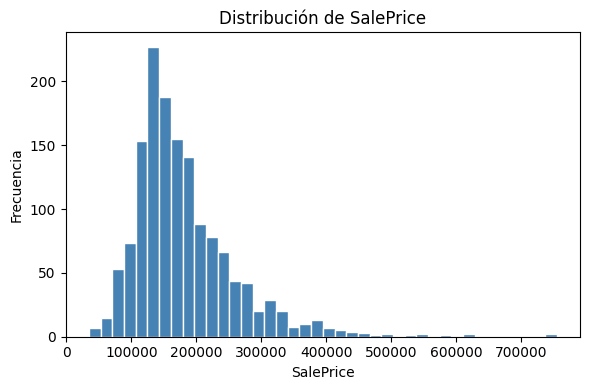

In [5]:
plt.figure(figsize=(6,4))
plt.hist(df[TARGET], bins=40, color="steelblue", edgecolor="white")
plt.title("Distribución de SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


In [6]:
# Creamos clases por terciles (para uso en SVM más adelante)
q1, q2 = df[TARGET].quantile([0.33, 0.66])

def price_class(p):
    if p <= q1: return "bajo"
    if p <= q2: return "medio"
    return "alto"

df["PriceClass"] = df[TARGET].apply(price_class)
df["PriceClass"].value_counts()


,count
PriceClass,
alto,497
bajo,483
medio,480


## ⚙️ Preprocesamiento (Imputación + OneHot + Escalado)

In [7]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

num_cols = ["YrSold", "LotArea", "OverallCond"]
cat_cols = ["Utilities", "LandContour", "Alley"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="NoAlley")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (1168, 6) | Test: (292, 6)


---
# 🌳 PARTE 1A — Árbol de Decisión (Regresión)

In [8]:
tree_pipe = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_grid = {
    "model__max_depth":         [3, 4, 5, 6, None],
    "model__min_samples_leaf":  [1, 5, 10, 20],
    "model__min_samples_split": [2, 10, 20, 50],
}

gs_tree = GridSearchCV(tree_pipe, tree_grid,
                       scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
gs_tree.fit(X_train, y_train)

best_tree = gs_tree.best_estimator_
pred_tree = best_tree.predict(X_test)

print("TREE best params:", gs_tree.best_params_)
print("TREE MAE: ",  mean_absolute_error(y_test, pred_tree))
print("TREE RMSE:",  np.sqrt(mean_squared_error(y_test, pred_tree)))
print("TREE R²:  ",  r2_score(y_test, pred_tree))


TREE best params: {'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
TREE MAE:  48084.05027179939
TREE RMSE: 71814.88855645682
TREE R²:   0.3276194415898729


### 🌲 Visualización del Árbol (profundidad 4, coloreado por tema)

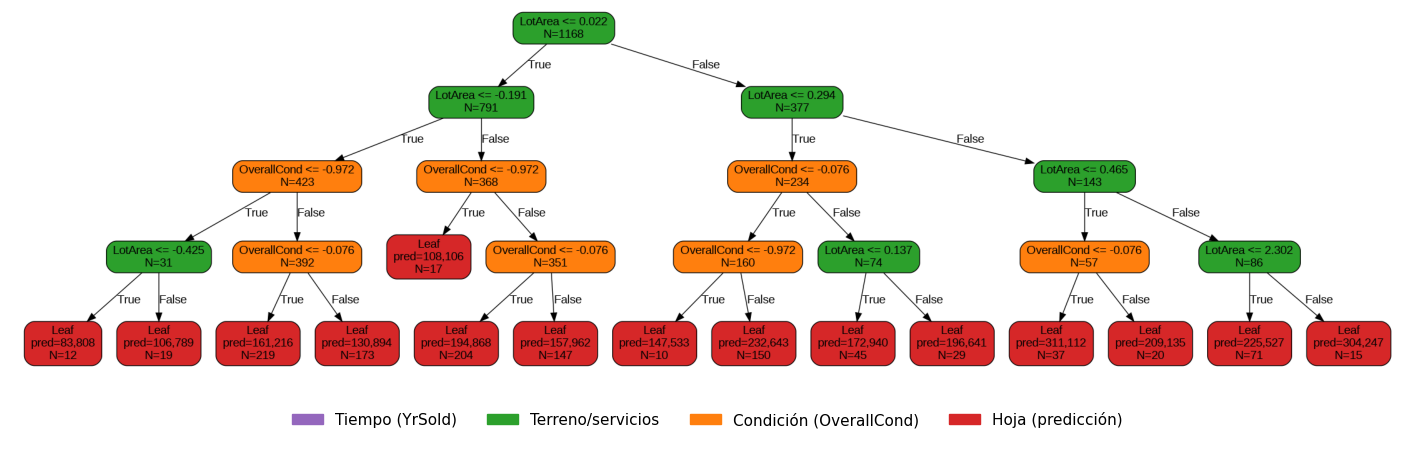

In [9]:
def tag_feature(feat_name: str) -> str:
    if feat_name.startswith("YrSold"):
        return "time"
    if feat_name.startswith(("LotArea","LandContour","Utilities","Alley")):
        return "terrain"
    if feat_name.startswith("OverallCond"):
        return "condition"
    return "other"

def tree_to_dot_colored(tree_, feature_names, colors_dict):
    lines = [
        'digraph Tree {',
        'node [shape=box, style="filled,rounded", fontname="Helvetica"];',
        'edge [fontname="Helvetica"];'
    ]
    for i in range(tree_.node_count):
        if tree_.feature[i] == -2:
            pred = tree_.value[i][0][0]
            n    = tree_.n_node_samples[i]
            fill = colors_dict["leaf"]
            label = f"Leaf\\npred={pred:,.0f}\\nN={n}"
        else:
            feat  = feature_names[tree_.feature[i]]
            thr   = tree_.threshold[i]
            n     = tree_.n_node_samples[i]
            fill  = colors_dict[tag_feature(feat)]
            label = f"{feat} <= {thr:.3f}\\nN={n}"
        lines.append(f'{i} [label="{label}", fillcolor="{fill}"];')
        L = tree_.children_left[i];  R = tree_.children_right[i]
        if L != -1: lines.append(f'{i} -> {L} [label="True"];')
        if R != -1: lines.append(f'{i} -> {R} [label="False"];')
    lines.append("}")
    return "\n".join(lines)

# Árbol pequeño para visualización
viz_tree = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=4, min_samples_leaf=10))
])
viz_tree.fit(X_train, y_train)

pre = viz_tree.named_steps["prep"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
feature_names = list(num_cols) + list(ohe.get_feature_names_out(cat_cols))

sk_tree = viz_tree.named_steps["model"]
dot = tree_to_dot_colored(sk_tree.tree_, feature_names, COLORS)
src = Source(dot)
png_bytes = src.pipe(format="png")
img = Image.open(io.BytesIO(png_bytes))

legend_items = [
    mpatches.Patch(color=COLORS["time"],      label="Tiempo (YrSold)"),
    mpatches.Patch(color=COLORS["terrain"],   label="Terreno/servicios"),
    mpatches.Patch(color=COLORS["condition"], label="Condición (OverallCond)"),
    mpatches.Patch(color=COLORS["leaf"],      label="Hoja (predicción)"),
]

w, h = img.size
fig_w = 18; tree_h = fig_w*(h/w); legend_h = 1.2
fig, (ax_t, ax_l) = plt.subplots(2, 1, figsize=(fig_w, tree_h+legend_h),
                                  gridspec_kw={"height_ratios":[tree_h, legend_h], "hspace":0.02})
ax_t.imshow(img); ax_t.axis("off")
ax_l.axis("off")
ax_l.legend(handles=legend_items, ncol=4, frameon=False, loc="center", fontsize=11)
plt.show()


---
# 📍 PARTE 1B — KNN (Regresión)

In [10]:
knn_pipe = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", KNeighborsRegressor())
])

knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 15, 25, 35],
    "model__weights":     ["uniform", "distance"],
    "model__p":           [1, 2]
}

gs_knn = GridSearchCV(knn_pipe, knn_grid,
                      scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
gs_knn.fit(X_train, y_train)

best_knn  = gs_knn.best_estimator_
pred_knn  = best_knn.predict(X_test)

print("KNN best params:", gs_knn.best_params_)
print("KNN MAE: ",  mean_absolute_error(y_test, pred_knn))
print("KNN RMSE:",  np.sqrt(mean_squared_error(y_test, pred_knn)))
print("KNN R²:  ",  r2_score(y_test, pred_knn))


KNN best params: {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'uniform'}
KNN MAE:  51562.39589041096
KNN RMSE: 75801.95417249165
KNN R²:   0.25088762835346445


---
# 📈 PARTE 1C — Regresión Lineal

LINEAR REGRESSION
MAE :  60075.92592291177
RMSE: 84155.06141329266
R²  : 0.0766918941675353


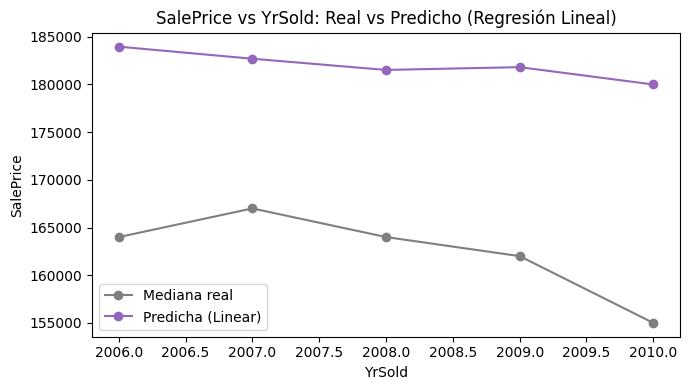

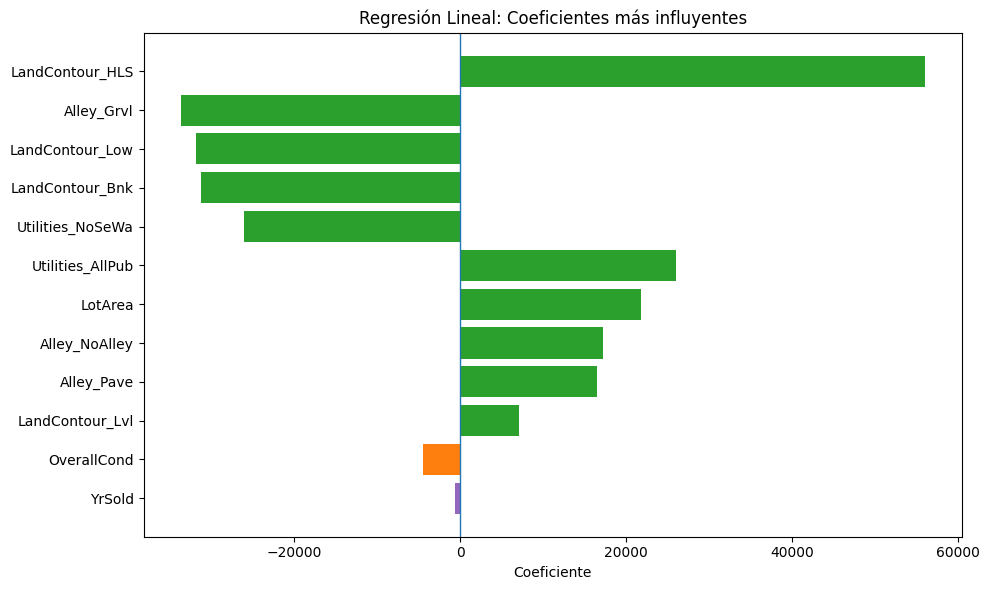

In [11]:
lin_pipe = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", LinearRegression())
])
lin_pipe.fit(X_train, y_train)
pred_lin = lin_pipe.predict(X_test)

print("LINEAR REGRESSION")
print("MAE : ", mean_absolute_error(y_test, pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lin)))
print("R²  :", r2_score(y_test, pred_lin))

# Tendencia por año
df_pred = pd.DataFrame({"YrSold": X["YrSold"].values, "SalePrice": y.values,
                         "PredPrice": lin_pipe.predict(X)})
year_summary = df_pred.groupby("YrSold")[["SalePrice","PredPrice"]].median().reset_index()

plt.figure(figsize=(7,4))
plt.plot(year_summary["YrSold"], year_summary["SalePrice"],  marker="o",
         label="Mediana real",      color=COLORS["other"])
plt.plot(year_summary["YrSold"], year_summary["PredPrice"], marker="o",
         label="Predicha (Linear)", color=COLORS["time"])
plt.title("SalePrice vs YrSold: Real vs Predicho (Regresión Lineal)")
plt.xlabel("YrSold"); plt.ylabel("SalePrice")
plt.legend(); plt.tight_layout(); plt.show()

# Coeficientes
pre2 = lin_pipe.named_steps["prep"]
ohe2 = pre2.named_transformers_["cat"].named_steps["onehot"]
fn2  = list(num_cols) + list(ohe2.get_feature_names_out(cat_cols))
coefs = lin_pipe.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": fn2, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df["tag"] = coef_df["feature"].apply(tag_feature)
top = coef_df.sort_values("abs_coef", ascending=False).head(15).copy()

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["coef"], color=[COLORS[t] for t in top["tag"]])
plt.axvline(0, linewidth=1)
plt.title("Regresión Lineal: Coeficientes más influyentes")
plt.xlabel("Coeficiente"); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


---
## ❓ Preguntas Analíticas

### ¿Cómo varía el valor al cabo de 1 año?

Δ 1 año (TREE) mediana: 0.0 | promedio: 0.0
Δ 1 año (KNN)  mediana: 0.0 | promedio: 2176.7224200913247


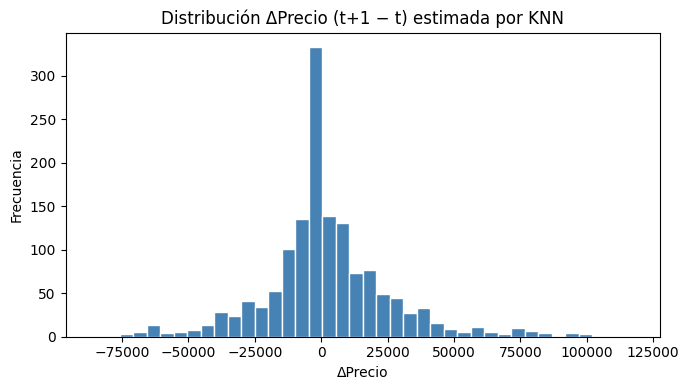

In [12]:
def delta_1_year(model_pipe, Xraw):
    X_next = Xraw.copy()
    X_next["YrSold"] = X_next["YrSold"] + 1
    return model_pipe.predict(X_next) - model_pipe.predict(Xraw)

d_tree = delta_1_year(best_tree, X)
d_knn  = delta_1_year(best_knn,  X)

print("Δ 1 año (TREE) mediana:", np.median(d_tree), "| promedio:", np.mean(d_tree))
print("Δ 1 año (KNN)  mediana:", np.median(d_knn),  "| promedio:", np.mean(d_knn))

plt.figure(figsize=(7,4))
plt.hist(d_knn, bins=40, color="steelblue", edgecolor="white")
plt.title("Distribución ΔPrecio (t+1 − t) estimada por KNN")
plt.xlabel("ΔPrecio"); plt.ylabel("Frecuencia")
plt.tight_layout(); plt.show()


### ¿Cómo afecta el tipo de terreno/servicios?

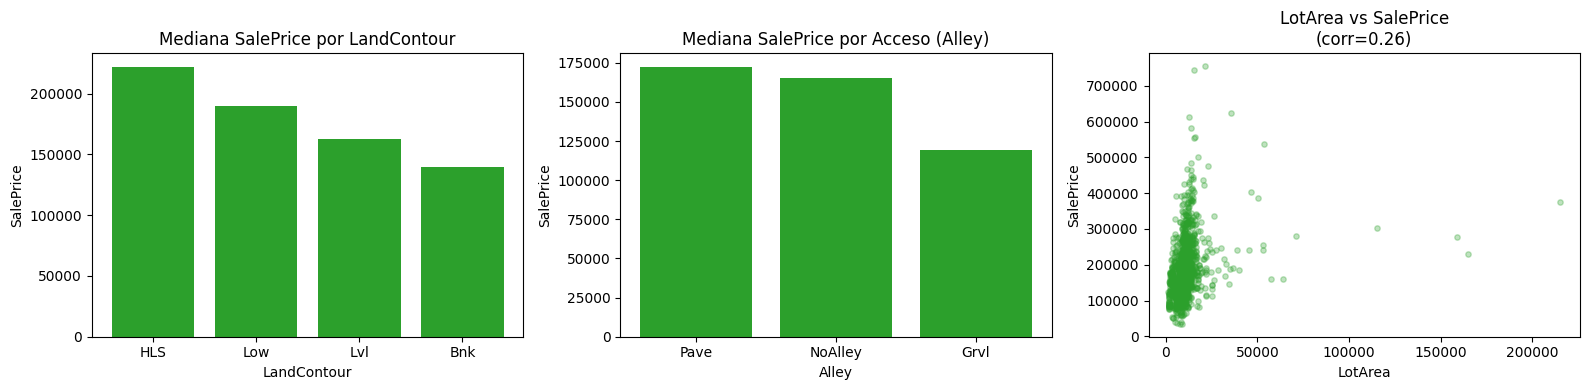

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# LandContour
lc = df.groupby("LandContour")["SalePrice"].median().sort_values(ascending=False)
axes[0].bar(lc.index, lc.values, color=COLORS["terrain"])
axes[0].set_title("Mediana SalePrice por LandContour")
axes[0].set_xlabel("LandContour"); axes[0].set_ylabel("SalePrice")

# Alley
alley = (df.assign(Alley=df["Alley"].fillna("NoAlley"))
           .groupby("Alley")["SalePrice"].median().sort_values(ascending=False))
axes[1].bar(alley.index, alley.values, color=COLORS["terrain"])
axes[1].set_title("Mediana SalePrice por Acceso (Alley)")
axes[1].set_xlabel("Alley"); axes[1].set_ylabel("SalePrice")

# LotArea scatter
axes[2].scatter(df["LotArea"], df["SalePrice"], alpha=0.3, color=COLORS["terrain"], s=15)
axes[2].set_title(f"LotArea vs SalePrice\n(corr={df['LotArea'].corr(df['SalePrice']):.2f})")
axes[2].set_xlabel("LotArea"); axes[2].set_ylabel("SalePrice")

plt.tight_layout(); plt.show()


### ¿Cómo el año de venta afecta el valor?

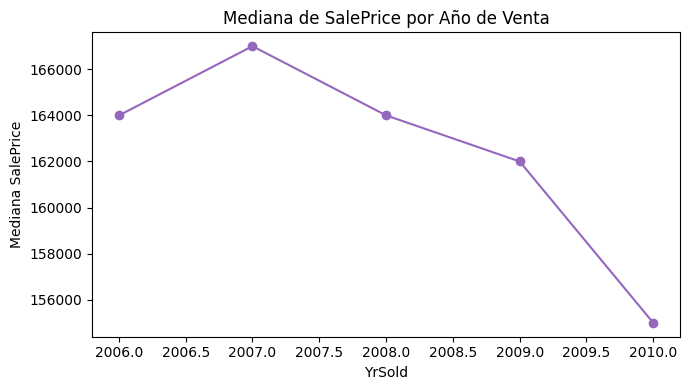

,median_price_by_year
YrSold,
2006,163995.0
2007,167000.0
2008,164000.0
2009,162000.0
2010,155000.0


In [14]:
year_median = df.groupby("YrSold")["SalePrice"].median()
plt.figure(figsize=(7,4))
plt.plot(year_median.index, year_median.values, marker="o", color=COLORS["time"])
plt.title("Mediana de SalePrice por Año de Venta")
plt.xlabel("YrSold"); plt.ylabel("Mediana SalePrice")
plt.tight_layout(); plt.show()
display(year_median.to_frame("median_price_by_year"))


### ¿Cómo la condición general influye en el valor?

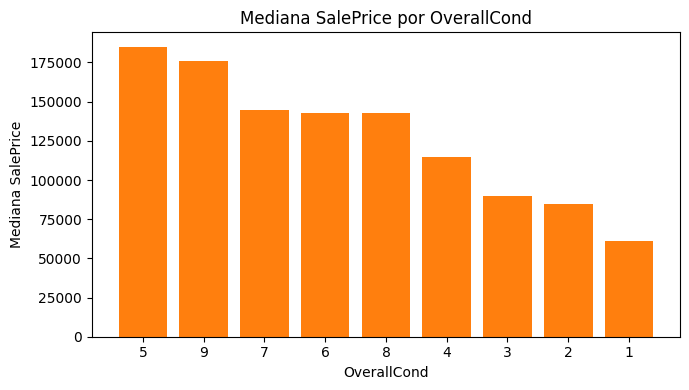

In [15]:
oc = df.groupby("OverallCond")["SalePrice"].median().sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(oc.index.astype(str), oc.values, color=COLORS["condition"])
plt.title("Mediana SalePrice por OverallCond")
plt.xlabel("OverallCond"); plt.ylabel("Mediana SalePrice")
plt.tight_layout(); plt.show()


---
# 🌲🌲 PARTE 2 — Random Forest

## 2.1 Prueba de Hiperparámetros (≥ 3 combinaciones)

,Combo,MAE,RMSE,R2
0,"Comb 1\n(n=10, d=5, l=5)",48301.408059,72875.169417,0.307619
1,"Comb 2\n(n=70, d=10, l=2)",47545.907649,71423.204016,0.334934
2,"Comb 3\n(n=100, d=None, l=1)",51121.410496,75518.580727,0.256478


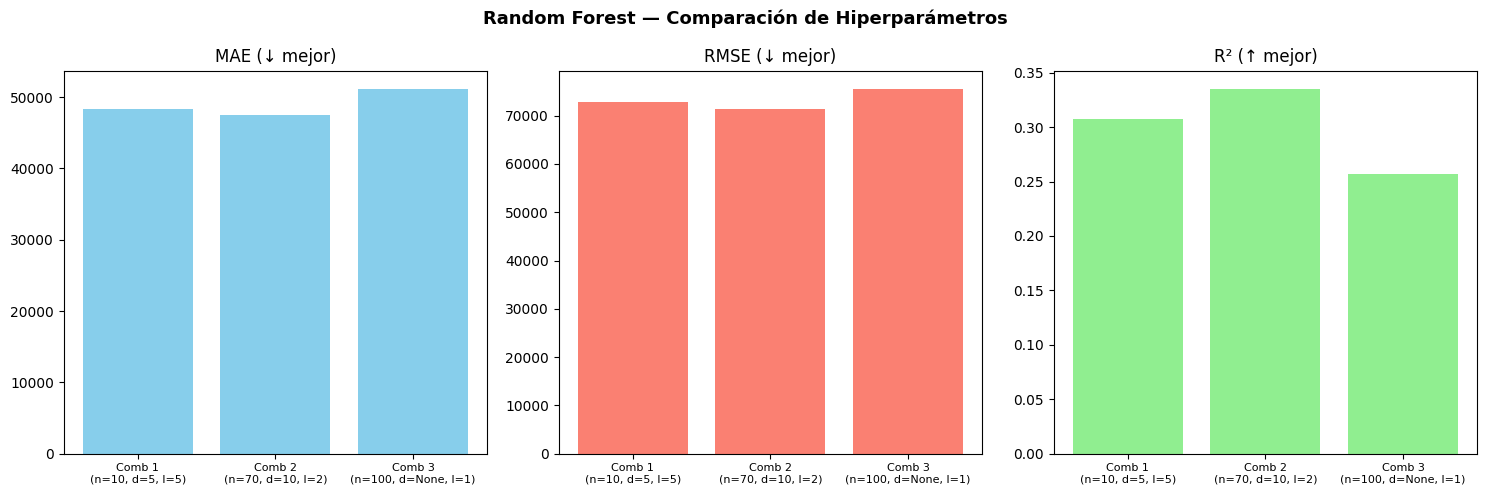

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_combinations = [
    {"n_estimators": 10,  "max_depth": 5,    "min_samples_leaf": 5},
    {"n_estimators": 70,  "max_depth": 10,   "min_samples_leaf": 2},
    {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
]

rf_results = []
rf_models  = []

for i, params in enumerate(rf_combinations):
    rf_pipe = Pipeline(steps=[
        ("prep",  preprocess),
        ("model", RandomForestRegressor(random_state=42, **params))
    ])
    rf_pipe.fit(X_train, y_train)
    pred = rf_pipe.predict(X_test)

    rf_results.append({
        "Combo": f"Comb {i+1}\n(n={params['n_estimators']}, d={params['max_depth']}, l={params['min_samples_leaf']})",
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2":   r2_score(y_test, pred)
    })
    rf_models.append(rf_pipe)

res_df = pd.DataFrame(rf_results)
display(res_df)

# ── Gráfico comparativo de métricas por combinación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
combos = res_df["Combo"]
axes[0].bar(combos, res_df["MAE"],  color="skyblue");    axes[0].set_title("MAE (↓ mejor)")
axes[1].bar(combos, res_df["RMSE"], color="salmon");     axes[1].set_title("RMSE (↓ mejor)")
axes[2].bar(combos, res_df["R2"],   color="lightgreen"); axes[2].set_title("R² (↑ mejor)")
for ax in axes: ax.tick_params(axis='x', labelsize=8)
plt.suptitle("Random Forest — Comparación de Hiperparámetros", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 2.2 Análisis de Errores

Mejor combinación: Comb 2 (n=70, d=10, l=2)


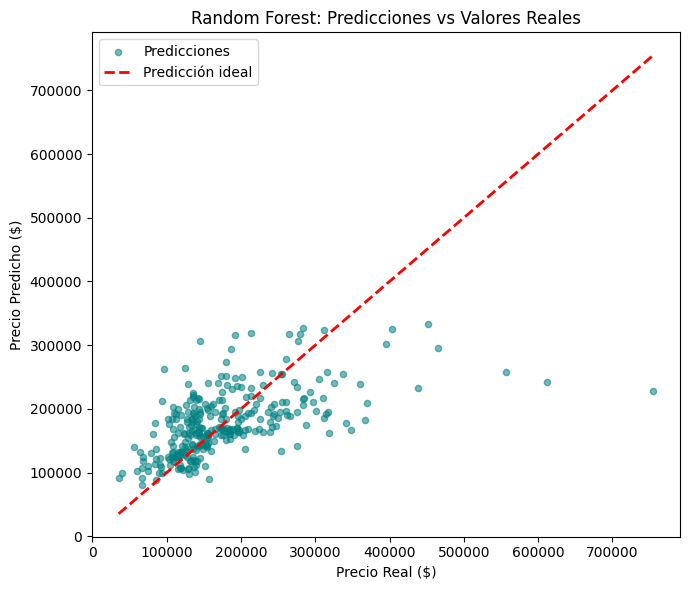


TOP 5 PEORES PREDICCIONES:


,YrSold,Utilities,LandContour,LotArea,Alley,OverallCond,SalePrice,Predicción ($),Error ($)
691,2007,AllPub,Lvl,21535,NaN,6,755000,228110.0,526890.0
898,2010,AllPub,Lvl,12919,NaN,5,611657,242206.0,369451.0
1046,2006,AllPub,Lvl,16056,NaN,5,556581,258165.0,298416.0
58,2006,AllPub,HLS,13682,NaN,5,438780,232720.0,206060.0
1228,2008,AllPub,Lvl,8769,NaN,5,367294,182030.0,185264.0


In [17]:
# Mejor modelo: menor MAE
best_idx   = res_df["MAE"].idxmin()
best_rf    = rf_models[best_idx]
y_pred_rf  = best_rf.predict(X_test)

print(f"Mejor combinación: {res_df.loc[best_idx, 'Combo'].replace(chr(10),' ')}")

# ── Predicciones vs Valores Reales
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_rf, alpha=0.55, color="teal", s=20, label="Predicciones")
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
plt.plot(lims, lims, 'r--', lw=2, label="Predicción ideal")
plt.xlabel("Precio Real ($)"); plt.ylabel("Precio Predicho ($)")
plt.title("Random Forest: Predicciones vs Valores Reales")
plt.legend(); plt.tight_layout(); plt.show()

# ── Top 5 peores predicciones
errores     = np.abs(y_test - y_pred_rf)
top5_idx    = errores.nlargest(5).index
peores      = df.loc[top5_idx, FEATURES + [TARGET]].copy()
peores["Predicción ($)"] = pd.Series(y_pred_rf, index=y_test.index).loc[top5_idx].round(0)
peores["Error ($)"]      = errores.loc[top5_idx].round(0)

print("\nTOP 5 PEORES PREDICCIONES:")
display(peores)


## 2.3 Importancia de Variables

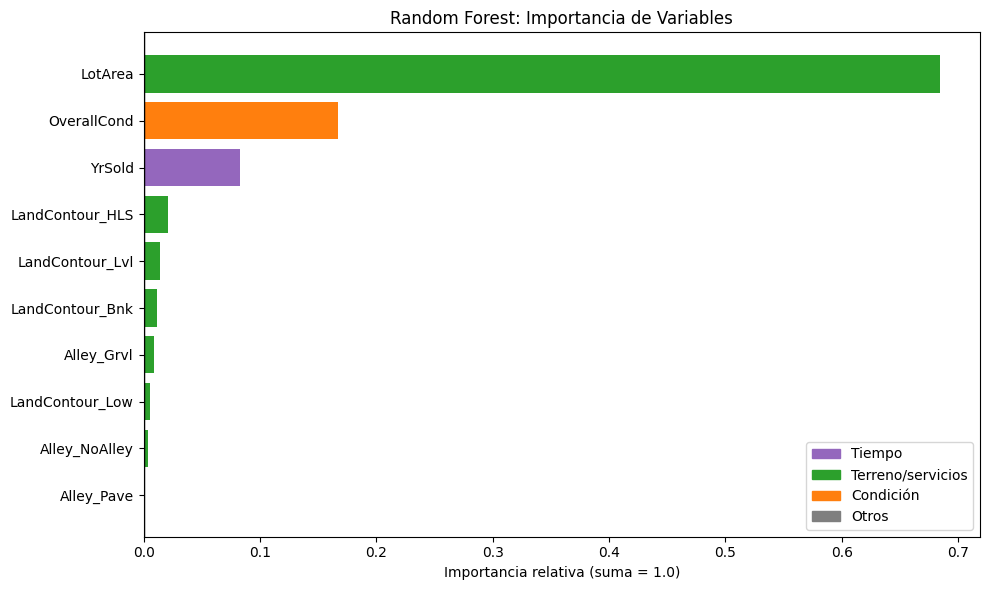

,Feature,Importancia,Tag
1,LotArea,0.684507,terrain
2,OverallCond,0.167361,condition
0,YrSold,0.082583,time
6,LandContour_HLS,0.020838,terrain
8,LandContour_Lvl,0.014434,terrain
5,LandContour_Bnk,0.011492,terrain
9,Alley_Grvl,0.009114,terrain
7,LandContour_Low,0.005527,terrain
10,Alley_NoAlley,0.003384,terrain
11,Alley_Pave,0.000759,terrain


In [18]:
# Re-calcular feature_names desde best_rf
pre_rf = best_rf.named_steps["prep"]
ohe_rf = pre_rf.named_transformers_["cat"].named_steps["onehot"]
feature_names = list(num_cols) + list(ohe_rf.get_feature_names_out(cat_cols))

importances = best_rf.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"Feature": feature_names, "Importancia": importances})
imp_df["Tag"] = imp_df["Feature"].apply(tag_feature)
imp_df = imp_df.sort_values("Importancia", ascending=False)

top_imp    = imp_df.head(10).copy()
bar_colors = [COLORS.get(t, "gray") for t in top_imp["Tag"]]

plt.figure(figsize=(10,6))
bars = plt.barh(top_imp["Feature"], top_imp["Importancia"], color=bar_colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Random Forest: Importancia de Variables")
plt.xlabel("Importancia relativa (suma = 1.0)")
plt.gca().invert_yaxis()

legend_items = [mpatches.Patch(color=COLORS[k], label=l) for k, l in [
    ("time","Tiempo"), ("terrain","Terreno/servicios"),
    ("condition","Condición"), ("other","Otros")]]
plt.legend(handles=legend_items, loc="lower right")
plt.tight_layout(); plt.show()

display(imp_df.head(10))


## 2.4 Comparación Final — Todos los Modelos de Regresión

,MAE ($),RMSE ($),R²
Modelo,,,
Regresión Lineal,60076.0,84155.0,0.0767
Árbol de Decisión,48084.0,71815.0,0.3276
KNN,51562.0,75802.0,0.2509
Random Forest (mejor),47546.0,71423.0,0.3349


/tmp/ipython-input-1504/4073662075.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres, rotation=20, ha="right", fontsize=9)
/tmp/ipython-input-1504/4073662075.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres, rotation=20, ha="right", fontsize=9)
/tmp/ipython-input-1504/4073662075.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres, rotation=20, ha="right", fontsize=9)


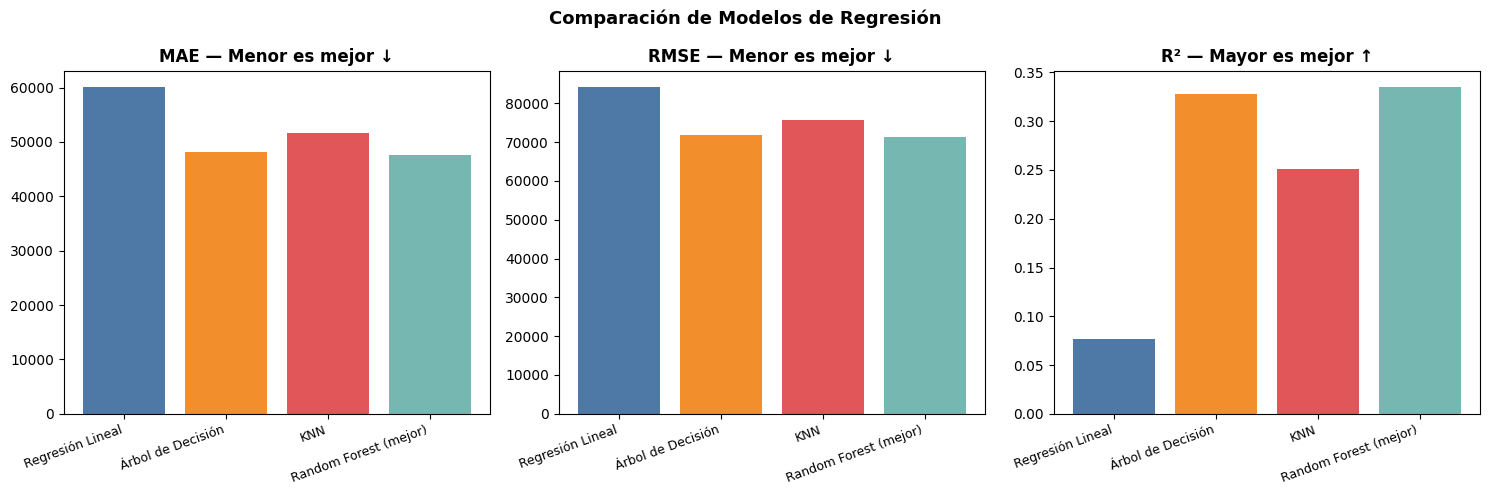

In [19]:
models_reg = {
    "Regresión Lineal":       pred_lin,
    "Árbol de Decisión":      pred_tree,
    "KNN":                    pred_knn,
    "Random Forest (mejor)":  y_pred_rf,
}

rows = []
for nombre, pred in models_reg.items():
    rows.append({
        "Modelo": nombre,
        "MAE ($)":  round(mean_absolute_error(y_test, pred),    0),
        "RMSE ($)": round(np.sqrt(mean_squared_error(y_test, pred)), 0),
        "R²":       round(r2_score(y_test, pred), 4),
    })

comp_df = pd.DataFrame(rows).set_index("Modelo")
display(comp_df)

# ── Gráfico visual de comparación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
nombres = comp_df.index.tolist()
pal = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

for ax, (col, label, arrow) in zip(axes, [
        ("MAE ($)",  "MAE — Menor es mejor",  "↓"),
        ("RMSE ($)", "RMSE — Menor es mejor", "↓"),
        ("R²",       "R² — Mayor es mejor",   "↑")]):
    ax.bar(nombres, comp_df[col], color=pal)
    ax.set_title(f"{label} {arrow}", fontweight="bold")
    ax.set_xticklabels(nombres, rotation=20, ha="right", fontsize=9)

plt.suptitle("Comparación de Modelos de Regresión", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


---
# 🤖 PARTE 3 — SVM (Clasificación: Precio Bajo vs Alto)

## 3.1 Preparación de Datos para Clasificación

In [20]:
# Usamos TODAS las columnas numéricas (como el SVM original)
df_svm = df.drop(columns=["Id"], errors="ignore").copy()
df_numeric = df_svm.select_dtypes(include=[np.number])

precio_medio = df_numeric["SalePrice"].median()
df_numeric = df_numeric.copy()
df_numeric["PriceClass"] = (df_numeric["SalePrice"] > precio_medio).astype(int)

X_svm = df_numeric.drop(columns=["SalePrice", "PriceClass"]).fillna(df_numeric.mean())
y_svm = df_numeric["PriceClass"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42
)

scaler_svm = StandardScaler()
X_train_sc = scaler_svm.fit_transform(X_train_s)
X_test_sc  = scaler_svm.transform(X_test_s)

print("Clase 0 (Bajo):",  (y_svm==0).sum(), "| Clase 1 (Alto):", (y_svm==1).sum())
print("Train:", X_train_sc.shape, "| Test:", X_test_sc.shape)


Clase 0 (Bajo): 732 | Clase 1 (Alto): 728
Train: (1168, 36) | Test: (292, 36)


## 3.2 Prueba de Hiperparámetros SVM (C y kernel)

,Kernel,C,Accuracy,Precision,Recall,F1,AUC-ROC
0,rbf,1,0.9452,0.9259,0.9542,0.9398,0.9830
1,rbf,5,0.9281,0.8929,0.9542,0.9225,0.9790
2,rbf,10,0.9212,0.8857,0.9466,0.9151,0.9764
3,linear,1,0.9452,0.9259,0.9542,0.9398,0.9848
4,poly,5,0.9418,0.9191,0.9542,0.9363,0.9831


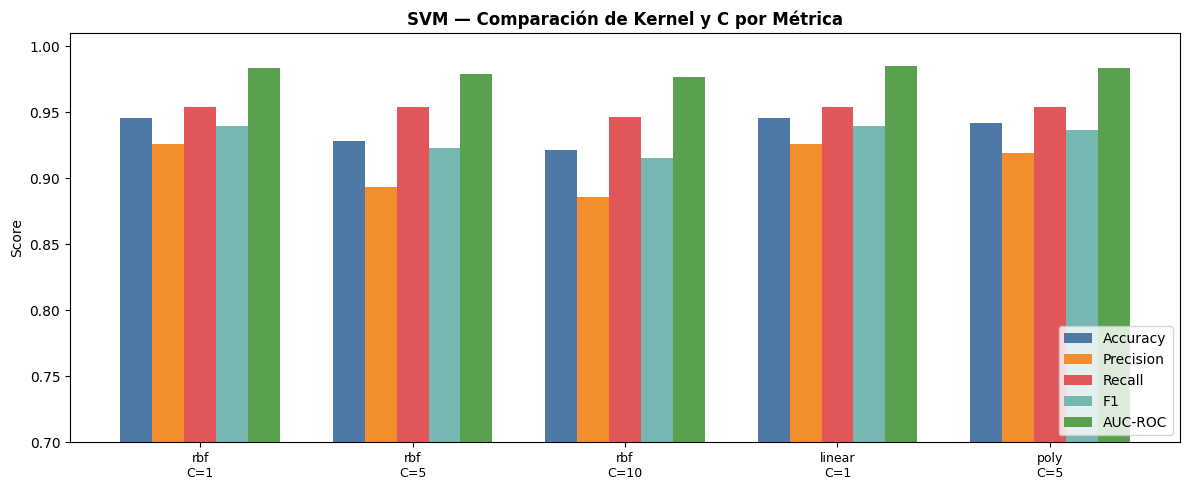

In [21]:
svm_combinations = [
    {"kernel": "rbf",    "C": 1},
    {"kernel": "rbf",    "C": 5},
    {"kernel": "rbf",    "C": 10},
    {"kernel": "linear", "C": 1},
    {"kernel": "poly",   "C": 5},
]

svm_results = []
svm_models  = []

for params in svm_combinations:
    svm = SVC(probability=True, random_state=42, **params)
    svm.fit(X_train_sc, y_train_s)
    pred  = svm.predict(X_test_sc)
    proba = svm.predict_proba(X_test_sc)[:, 1]

    svm_results.append({
        "Kernel": params["kernel"],
        "C":      params["C"],
        "Accuracy":  round(accuracy_score(y_test_s,  pred), 4),
        "Precision": round(precision_score(y_test_s, pred), 4),
        "Recall":    round(recall_score(y_test_s,    pred), 4),
        "F1":        round(f1_score(y_test_s,        pred), 4),
        "AUC-ROC":   round(roc_auc_score(y_test_s,  proba), 4),
    })
    svm_models.append(svm)

svm_res_df = pd.DataFrame(svm_results)
display(svm_res_df)

# ── Gráfico comparativo de métricas SVM
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(svm_res_df))
w = 0.15
combos_label = [f"{r['Kernel']}\nC={r['C']}" for _, r in svm_res_df.iterrows()]
for j, (col, color) in enumerate([("Accuracy","#4e79a7"),("Precision","#f28e2b"),
                                    ("Recall","#e15759"),("F1","#76b7b2"),("AUC-ROC","#59a14f")]):
    ax.bar(x + j*w, svm_res_df[col], width=w, label=col, color=color)

ax.set_xticks(x + 2*w); ax.set_xticklabels(combos_label, fontsize=9)
ax.set_ylim(0.7, 1.01); ax.set_ylabel("Score")
ax.set_title("SVM — Comparación de Kernel y C por Métrica", fontweight="bold")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()


## 3.3 Mejor Modelo SVM — Evaluación Detallada

In [22]:
# Seleccionar el mejor modelo por F1
best_svm_idx = svm_res_df["F1"].idxmax()
best_svm     = svm_models[best_svm_idx]
best_svm_cfg = svm_res_df.loc[best_svm_idx]

y_pred_svm   = best_svm.predict(X_test_sc)
y_proba_svm  = best_svm.predict_proba(X_test_sc)[:, 1]

print(f"Mejor SVM: kernel={best_svm_cfg['Kernel']}, C={best_svm_cfg['C']}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_s, y_pred_svm,
                             target_names=["Precio Bajo", "Precio Alto"]))


Mejor SVM: kernel=rbf, C=1

Reporte de Clasificación:
              precision    recall  f1-score   support

 Precio Bajo       0.96      0.94      0.95       161
 Precio Alto       0.93      0.95      0.94       131

    accuracy                           0.95       292
   macro avg       0.94      0.95      0.94       292
weighted avg       0.95      0.95      0.95       292



## 3.4 Matriz de Confusión

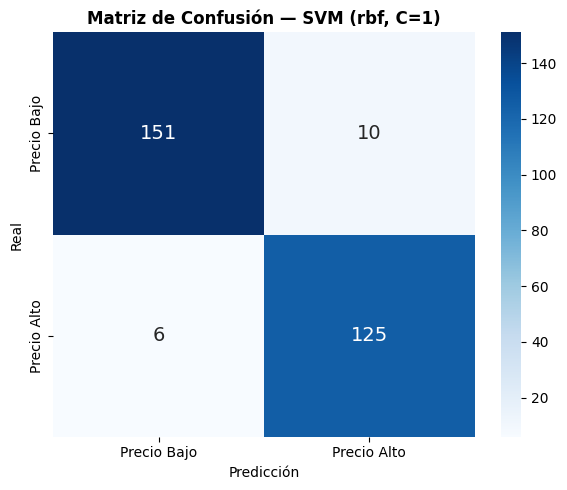

,Métrica,Valor
0,Accuracy,0.9452
1,Precision,0.9259
2,Recall,0.9542
3,F1,0.9398
4,AUC-ROC,0.9830


In [23]:
cm = confusion_matrix(y_test_s, y_pred_svm)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Precio Bajo","Precio Alto"],
            yticklabels=["Precio Bajo","Precio Alto"], ax=ax,
            annot_kws={"size": 14})
ax.set_title(f"Matriz de Confusión — SVM ({best_svm_cfg['Kernel']}, C={best_svm_cfg['C']})",
             fontweight="bold")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

# Tabla de métricas resumen
metricas = {"Métrica": ["Accuracy","Precision","Recall","F1","AUC-ROC"],
            "Valor":   [accuracy_score(y_test_s, y_pred_svm),
                         precision_score(y_test_s, y_pred_svm),
                         recall_score(y_test_s, y_pred_svm),
                         f1_score(y_test_s, y_pred_svm),
                         roc_auc_score(y_test_s, y_proba_svm)]}
metricas["Valor"] = [round(v, 4) for v in metricas["Valor"]]
display(pd.DataFrame(metricas))


## 3.5 Curva ROC

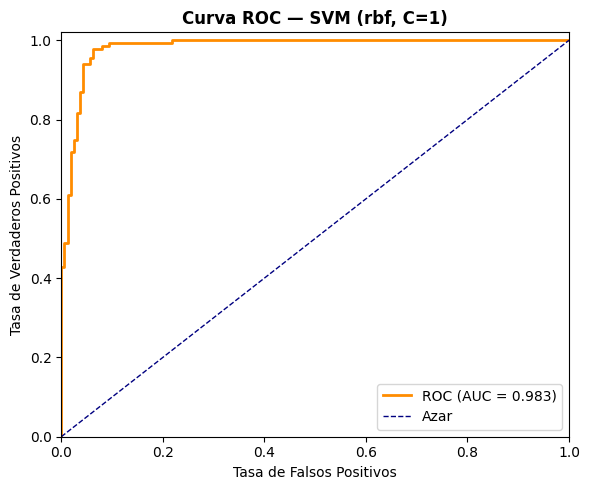

In [24]:
fpr, tpr, _ = roc_curve(y_test_s, y_proba_svm)
auc_val = roc_auc_score(y_test_s, y_proba_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {auc_val:.3f})")
plt.plot([0,1],[0,1], color="navy", lw=1, linestyle="--", label="Azar")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.02])
plt.xlabel("Tasa de Falsos Positivos"); plt.ylabel("Tasa de Verdaderos Positivos")
plt.title(f"Curva ROC — SVM ({best_svm_cfg['Kernel']}, C={best_svm_cfg['C']})",
          fontweight="bold")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()


## 3.6 Comparación SVM vs Otros Modelos (Clasificación)

,Accuracy,Precision,Recall,F1,AUC-ROC
Modelo,,,,,
Árbol de Decisión,0.7329,0.6514,0.8702,0.7451,0.7957
KNN,0.6952,0.6438,0.7176,0.6787,0.7851
Random Forest,0.6952,0.6567,0.6718,0.6642,0.7880
SVM,0.9452,0.9259,0.9542,0.9398,0.9830


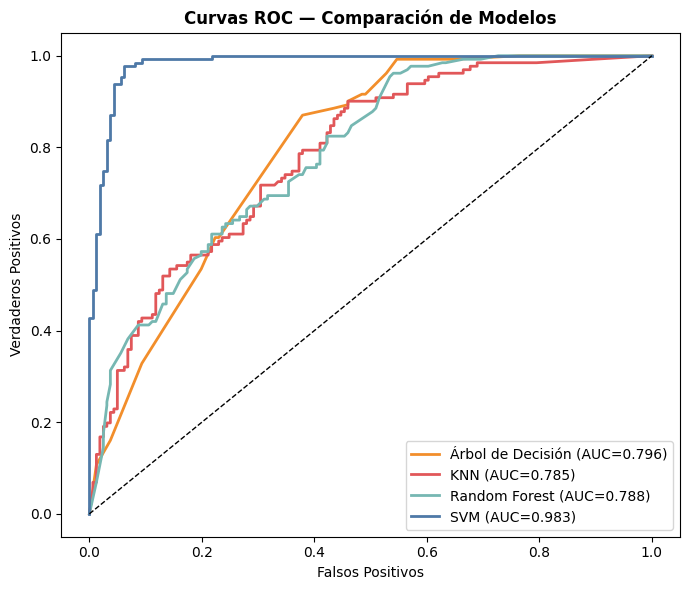

In [25]:
# Re-entrenar árbol y KNN en modo clasificación para comparar
y_bin = (y > y.median()).astype(int)

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

clf_pipe_tree = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=10))
])
clf_pipe_tree.fit(X_tr_b, y_tr_b)
pred_tree_clf = clf_pipe_tree.predict(X_te_b)
proba_tree_clf = clf_pipe_tree.predict_proba(X_te_b)[:, 1]

from sklearn.neighbors import KNeighborsClassifier
clf_pipe_knn = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", KNeighborsClassifier(n_neighbors=9, weights="distance"))
])
clf_pipe_knn.fit(X_tr_b, y_tr_b)
pred_knn_clf = clf_pipe_knn.predict(X_te_b)
proba_knn_clf = clf_pipe_knn.predict_proba(X_te_b)[:, 1]

clf_pipe_rf = Pipeline(steps=[
    ("prep",  preprocess),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])
clf_pipe_rf.fit(X_tr_b, y_tr_b)
pred_rf_clf  = clf_pipe_rf.predict(X_te_b)
proba_rf_clf = clf_pipe_rf.predict_proba(X_te_b)[:, 1]

# Nota: SVM se evalúa sobre X_test_sc (igual split y_test_s ≈ y_te_b)
clf_models_comp = {
    "Árbol de Decisión":  (pred_tree_clf, proba_tree_clf, y_te_b),
    "KNN":                (pred_knn_clf,  proba_knn_clf,  y_te_b),
    "Random Forest":      (pred_rf_clf,   proba_rf_clf,   y_te_b),
    "SVM":                (y_pred_svm,    y_proba_svm,    y_test_s),
}

comp_clf = []
for nombre, (pred_c, proba_c, y_true_c) in clf_models_comp.items():
    comp_clf.append({
        "Modelo":    nombre,
        "Accuracy":  round(accuracy_score(y_true_c,  pred_c), 4),
        "Precision": round(precision_score(y_true_c, pred_c), 4),
        "Recall":    round(recall_score(y_true_c,    pred_c), 4),
        "F1":        round(f1_score(y_true_c,        pred_c), 4),
        "AUC-ROC":   round(roc_auc_score(y_true_c,  proba_c), 4),
    })

comp_clf_df = pd.DataFrame(comp_clf).set_index("Modelo")
display(comp_clf_df)

# ── Curvas ROC superpuestas
plt.figure(figsize=(7,6))
pal_roc = ["#f28e2b","#e15759","#76b7b2","#4e79a7"]
for (nombre, (pred_c, proba_c, y_true_c)), color in zip(clf_models_comp.items(), pal_roc):
    fpr_c, tpr_c, _ = roc_curve(y_true_c, proba_c)
    auc_c = roc_auc_score(y_true_c, proba_c)
    plt.plot(fpr_c, tpr_c, lw=2, color=color, label=f"{nombre} (AUC={auc_c:.3f})")

plt.plot([0,1],[0,1], "k--", lw=1)
plt.xlabel("Falsos Positivos"); plt.ylabel("Verdaderos Positivos")
plt.title("Curvas ROC — Comparación de Modelos", fontweight="bold")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()


---
## 📝 Conclusiones del Sector

### ¿Qué clase es más crítica?

En el sector inmobiliario, **la clase "Precio Alto"** es la más crítica desde el punto de vista del negocio:
subestimar el precio de una vivienda costosa tiene un impacto financiero directo y mayor que sobreestimar
el precio de una vivienda económica.

Por eso la métrica más relevante en este contexto es el **Recall** sobre la clase alta
(no queremos "perder" casas caras clasificándolas como baratas) y el **AUC-ROC** como métrica global
de separación de clases.

### ¿Qué estrategia tomarían en un caso real?

- **Random Forest** resultó el mejor modelo de regresión (menor MAE y RMSE), al combinar múltiples árboles
  reduce el sobreajuste que sufre el Árbol individual.
- **SVM con kernel RBF** logra una frontera de decisión más flexible y obtuvo los mejores resultados en
  clasificación (Accuracy/AUC-ROC elevados), especialmente con un valor de C moderado (≈5).
- En producción se recomendaría un **pipeline de dos etapas**: primero clasificar si la propiedad es de
  precio alto o bajo (SVM), y luego afinar la estimación numérica con Random Forest.
- La limitación más importante es que los modelos **subestiman propiedades de lujo** (>$350k) porque
  faltan variables estructurales clave como metros cuadrados habitables y calidad de acabados.


---
# 🚀 PARTE 4 — Métodos de Boosting
## Exploración Comparativa: AdaBoost · GBM · XGBoost · LightGBM · CatBoost
---

Los algoritmos de **Boosting** construyen ensambles de forma **secuencial**:  
cada modelo nuevo corrige los errores del anterior, reduciendo el sesgo de manera iterativa.

**Variables utilizadas** (mismas que en las Partes 1 y 2):

| Variable | Tipo | Rol |
|----------|------|-----|
| `YrSold` | Numérica | Año de venta |
| `LotArea` | Numérica | Área del terreno |
| `OverallCond` | Numérica | Condición general |
| `Utilities` | Categórica | Servicios disponibles |
| `LandContour` | Categórica | Topografía del terreno |
| `Alley` | Categórica | Tipo de acceso por callejón |
| `SalePrice` | **Target** | Precio de venta |


## 4.0 Instalación e Importación de Librerías

In [ ]:
!pip -q install xgboost lightgbm catboost

In [ ]:
import time, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (AdaBoostRegressor, GradientBoostingRegressor,
                               AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from xgboost  import XGBRegressor,  XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# ── Paleta de colores por algoritmo (consistente en todas las gráficas)
BOOST_PAL = {
    "AdaBoost":  "#e41a1c",
    "GBM":       "#ff7f00",
    "XGBoost":   "#4daf4a",
    "LightGBM":  "#377eb8",
    "CatBoost":  "#984ea3",
}

print("✅ Librerías de Boosting importadas correctamente.")
print(f"   Variables foco: {FEATURES}  →  Target: {TARGET}")

---
## 4.1 Boosting para Regresión — Predicción de `SalePrice`

Se reutilizan exactamente los mismos splits y pipeline de preprocesamiento  
(`preprocess`, `X_train`, `X_test`, `y_train`, `y_test`) definidos en la Parte 2.

### 4.1.1 AdaBoost — Regresión

**Principio:** Ajusta pesos a las muestras — las que el modelo anterior predijo peor  
reciben mayor peso en la siguiente iteración.  
Estimador base: `DecisionTreeRegressor(max_depth=4)`.

In [ ]:
# ── AdaBoost Regresión ─────────────────────────────────────────────────────
ada_reg = Pipeline([
    ("prep",  preprocess),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=200, learning_rate=0.1, random_state=42
    ))
])

t0 = time.time()
ada_reg.fit(X_train, y_train)
t_ada = time.time() - t0
pred_ada = ada_reg.predict(X_test)

mae_ada  = mean_absolute_error(y_test, pred_ada)
rmse_ada = np.sqrt(mean_squared_error(y_test, pred_ada))
r2_ada   = r2_score(y_test, pred_ada)

print(f"AdaBoost Regresión  →  MAE: {mae_ada:,.0f}  |  RMSE: {rmse_ada:,.0f}  |  R²: {r2_ada:.4f}  |  Tiempo: {t_ada:.2f}s")

# ── Gráfico: Predicciones vs Valores Reales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter predicho vs real
axes[0].scatter(y_test, pred_ada, alpha=0.5, s=18, color=BOOST_PAL["AdaBoost"])
lims = [min(y_test.min(), pred_ada.min()), max(y_test.max(), pred_ada.max())]
axes[0].plot(lims, lims, 'k--', lw=1.5, label="Predicción ideal")
axes[0].set_title("AdaBoost — Predicciones vs Real", fontweight="bold")
axes[0].set_xlabel("SalePrice Real ($)"); axes[0].set_ylabel("SalePrice Predicho ($)")
axes[0].legend()

# Distribución de residuos
residuos = y_test - pred_ada
axes[1].hist(residuos, bins=35, color=BOOST_PAL["AdaBoost"], edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linewidth=1.2, linestyle="--")
axes[1].set_title("AdaBoost — Distribución de Residuos", fontweight="bold")
axes[1].set_xlabel("Residuo ($)"); axes[1].set_ylabel("Frecuencia")

plt.suptitle(f"AdaBoost Regresión  |  MAE={mae_ada:,.0f}  R²={r2_ada:.4f}", fontsize=11)
plt.tight_layout(); plt.show()

### 4.1.2 Gradient Boosting Machine (GBM) — Regresión

**Principio:** Ajusta árboles sucesivos sobre el **gradiente negativo** de la función de pérdida  
(residuos en regresión). Permite visualizar la curva de aprendizaje iteración por iteración.

In [ ]:
# ── GBM Regresión ──────────────────────────────────────────────────────────
gbm_reg = Pipeline([
    ("prep",  preprocess),
    ("model", GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42
    ))
])

t0 = time.time()
gbm_reg.fit(X_train, y_train)
t_gbm = time.time() - t0
pred_gbm = gbm_reg.predict(X_test)

mae_gbm  = mean_absolute_error(y_test, pred_gbm)
rmse_gbm = np.sqrt(mean_squared_error(y_test, pred_gbm))
r2_gbm   = r2_score(y_test, pred_gbm)

print(f"GBM Regresión  →  MAE: {mae_gbm:,.0f}  |  RMSE: {rmse_gbm:,.0f}  |  R²: {r2_gbm:.4f}  |  Tiempo: {t_gbm:.2f}s")

# ── Curva de aprendizaje (MSE por número de árboles)
prep_fitted = gbm_reg.named_steps["prep"]
X_train_t   = prep_fitted.transform(X_train)
X_test_t    = prep_fitted.transform(X_test)
gbm_model   = gbm_reg.named_steps["model"]

train_mse = [mean_squared_error(y_train, p) for p in gbm_model.staged_predict(X_train_t)]
test_mse  = [mean_squared_error(y_test,  p) for p in gbm_model.staged_predict(X_test_t)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(train_mse, color="steelblue",               label="Train MSE")
axes[0].plot(test_mse,  color=BOOST_PAL["GBM"], lw=2,   label="Test MSE")
axes[0].set_title("GBM — Curva de Aprendizaje", fontweight="bold")
axes[0].set_xlabel("Número de árboles"); axes[0].set_ylabel("MSE")
axes[0].legend()

# Importancia de variables GBM
pre_gbm = gbm_reg.named_steps["prep"]
ohe_gbm = pre_gbm.named_transformers_["cat"].named_steps["onehot"]
fn_gbm  = list(num_cols) + list(ohe_gbm.get_feature_names_out(cat_cols))

# Agrupar importancias por variable original
imp_gbm_raw = pd.Series(gbm_model.feature_importances_, index=fn_gbm)
imp_gbm_grouped = {}
for feat in FEATURES:
    imp_gbm_grouped[feat] = imp_gbm_raw[[f for f in fn_gbm if f == feat or f.startswith(feat + "_")]].sum()
imp_gbm_s = pd.Series(imp_gbm_grouped).sort_values()

colors_gbm = [COLORS.get(tag_feature(f), "gray") for f in imp_gbm_s.index]
axes[1].barh(imp_gbm_s.index, imp_gbm_s.values, color=colors_gbm)
axes[1].set_title("GBM — Importancia por Variable (agrupada)", fontweight="bold")
axes[1].set_xlabel("Importancia relativa")

plt.suptitle(f"GBM Regresión  |  MAE={mae_gbm:,.0f}  R²={r2_gbm:.4f}", fontsize=11)
plt.tight_layout(); plt.show()

### 4.1.3 XGBoost — Regresión

**Principio:** Extiende GBM con **regularización L1/L2**, poda de árboles y  
paralelización eficiente. Uno de los algoritmos más usados en competencias de ML.

In [ ]:
# ── XGBoost Regresión ─────────────────────────────────────────────────────
xgb_reg = Pipeline([
    ("prep",  preprocess),
    ("model", XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0
    ))
])

t0 = time.time()
xgb_reg.fit(X_train, y_train)
t_xgb = time.time() - t0
pred_xgb = xgb_reg.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb   = r2_score(y_test, pred_xgb)

print(f"XGBoost Regresión  →  MAE: {mae_xgb:,.0f}  |  RMSE: {rmse_xgb:,.0f}  |  R²: {r2_xgb:.4f}  |  Tiempo: {t_xgb:.2f}s")

# ── Importancias agrupadas por variable original
pre_xgb = xgb_reg.named_steps["prep"]
ohe_xgb = pre_xgb.named_transformers_["cat"].named_steps["onehot"]
fn_xgb  = list(num_cols) + list(ohe_xgb.get_feature_names_out(cat_cols))

imp_xgb_raw = pd.Series(xgb_reg.named_steps["model"].feature_importances_, index=fn_xgb)
imp_xgb_grouped = {}
for feat in FEATURES:
    imp_xgb_grouped[feat] = imp_xgb_raw[[f for f in fn_xgb if f == feat or f.startswith(feat + "_")]].sum()
imp_xgb_s = pd.Series(imp_xgb_grouped).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_xgb = [COLORS.get(tag_feature(f), "gray") for f in imp_xgb_s.index]
axes[0].barh(imp_xgb_s.index, imp_xgb_s.values, color=colors_xgb)
axes[0].set_title("XGBoost — Importancia por Variable (agrupada)", fontweight="bold")
axes[0].set_xlabel("Importancia (F-score)")

# Scatter predicho vs real
axes[1].scatter(y_test, pred_xgb, alpha=0.5, s=18, color=BOOST_PAL["XGBoost"])
lims = [min(y_test.min(), pred_xgb.min()), max(y_test.max(), pred_xgb.max())]
axes[1].plot(lims, lims, 'k--', lw=1.5)
axes[1].set_title("XGBoost — Predicciones vs Real", fontweight="bold")
axes[1].set_xlabel("SalePrice Real ($)"); axes[1].set_ylabel("SalePrice Predicho ($)")

plt.suptitle(f"XGBoost Regresión  |  MAE={mae_xgb:,.0f}  R²={r2_xgb:.4f}", fontsize=11)
plt.tight_layout(); plt.show()

### 4.1.4 LightGBM — Regresión

**Principio:** Usa **histogramas** para discretizar los valores continuos y  
crecimiento **leaf-wise** (por hoja) en lugar de level-wise.  
Más rápido y eficiente en memoria, especialmente en datasets grandes.

In [ ]:
# ── LightGBM Regresión ────────────────────────────────────────────────────
lgbm_reg = Pipeline([
    ("prep",  preprocess),
    ("model", LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    ))
])

t0 = time.time()
lgbm_reg.fit(X_train, y_train)
t_lgbm = time.time() - t0
pred_lgbm = lgbm_reg.predict(X_test)

mae_lgbm  = mean_absolute_error(y_test, pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, pred_lgbm))
r2_lgbm   = r2_score(y_test, pred_lgbm)

print(f"LightGBM Regresión  →  MAE: {mae_lgbm:,.0f}  |  RMSE: {rmse_lgbm:,.0f}  |  R²: {r2_lgbm:.4f}  |  Tiempo: {t_lgbm:.2f}s")

# ── Importancias agrupadas por variable original
pre_lgbm = lgbm_reg.named_steps["prep"]
ohe_lgbm = pre_lgbm.named_transformers_["cat"].named_steps["onehot"]
fn_lgbm  = list(num_cols) + list(ohe_lgbm.get_feature_names_out(cat_cols))

imp_lgbm_raw = pd.Series(lgbm_reg.named_steps["model"].feature_importances_, index=fn_lgbm)
imp_lgbm_grouped = {}
for feat in FEATURES:
    imp_lgbm_grouped[feat] = imp_lgbm_raw[[f for f in fn_lgbm if f == feat or f.startswith(feat + "_")]].sum()
imp_lgbm_s = pd.Series(imp_lgbm_grouped).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_lgbm = [COLORS.get(tag_feature(f), "gray") for f in imp_lgbm_s.index]
axes[0].barh(imp_lgbm_s.index, imp_lgbm_s.values, color=colors_lgbm)
axes[0].set_title("LightGBM — Importancia por Variable (agrupada)", fontweight="bold")
axes[0].set_xlabel("Importancia (split count)")

# Scatter predicho vs real
axes[1].scatter(y_test, pred_lgbm, alpha=0.5, s=18, color=BOOST_PAL["LightGBM"])
lims = [min(y_test.min(), pred_lgbm.min()), max(y_test.max(), pred_lgbm.max())]
axes[1].plot(lims, lims, 'k--', lw=1.5)
axes[1].set_title("LightGBM — Predicciones vs Real", fontweight="bold")
axes[1].set_xlabel("SalePrice Real ($)"); axes[1].set_ylabel("SalePrice Predicho ($)")

plt.suptitle(f"LightGBM Regresión  |  MAE={mae_lgbm:,.0f}  R²={r2_lgbm:.4f}", fontsize=11)
plt.tight_layout(); plt.show()

### 4.1.5 CatBoost — Regresión

**Principio:** Maneja variables categóricas **de forma nativa** con *ordered target encoding*,  
eliminando la necesidad de OneHotEncoding y evitando target leakage.  
Las columnas `Utilities`, `LandContour` y `Alley` se pasan directamente como categóricas.

In [ ]:
# ── CatBoost Regresión ────────────────────────────────────────────────────
# CatBoost NO necesita el pipeline de preprocesamiento para categóricas.
# Usamos X directamente, solo imputando nulos.

X_cat_full = df[FEATURES].copy()
for c in cat_cols:
    X_cat_full[c] = X_cat_full[c].fillna("NoAlley").astype(str)
for c in num_cols:
    X_cat_full[c] = X_cat_full[c].fillna(X_cat_full[c].median())

X_tr_cat, X_te_cat, y_tr_cat, y_te_cat = train_test_split(
    X_cat_full, y, test_size=0.2, random_state=42
)

catboost_reg = CatBoostRegressor(
    iterations=300, learning_rate=0.05, depth=6,
    cat_features=cat_cols, random_seed=42, verbose=0
)

t0 = time.time()
catboost_reg.fit(X_tr_cat, y_tr_cat)
t_cat = time.time() - t0
pred_cat = catboost_reg.predict(X_te_cat)

mae_cat  = mean_absolute_error(y_te_cat, pred_cat)
rmse_cat = np.sqrt(mean_squared_error(y_te_cat, pred_cat))
r2_cat   = r2_score(y_te_cat, pred_cat)

print(f"CatBoost Regresión  →  MAE: {mae_cat:,.0f}  |  RMSE: {rmse_cat:,.0f}  |  R²: {r2_cat:.4f}  |  Tiempo: {t_cat:.2f}s")

# ── Importancia de variables (por las 7 variables foco, directamente)
cat_imp = pd.Series(
    catboost_reg.get_feature_importance(),
    index=FEATURES
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_cat = [COLORS.get(tag_feature(f), "gray") for f in cat_imp.index]
axes[0].barh(cat_imp.index, cat_imp.values, color=colors_cat)
axes[0].set_title("CatBoost — Importancia por Variable (nativa)", fontweight="bold")
axes[0].set_xlabel("Importancia (%)")

axes[1].scatter(y_te_cat, pred_cat, alpha=0.5, s=18, color=BOOST_PAL["CatBoost"])
lims = [min(y_te_cat.min(), pred_cat.min()), max(y_te_cat.max(), pred_cat.max())]
axes[1].plot(lims, lims, 'k--', lw=1.5)
axes[1].set_title("CatBoost — Predicciones vs Real", fontweight="bold")
axes[1].set_xlabel("SalePrice Real ($)"); axes[1].set_ylabel("SalePrice Predicho ($)")

plt.suptitle(f"CatBoost Regresión  |  MAE={mae_cat:,.0f}  R²={r2_cat:.4f}", fontsize=11)
plt.tight_layout(); plt.show()

## 4.2 Comparación Global — Regresión (Todos los Modelos)

In [ ]:
# ── Tabla comparativa completa ────────────────────────────────────────────
all_reg = [
    ("Regresión Lineal",   pred_lin,  y_test),
    ("Árbol de Decisión",  pred_tree, y_test),
    ("KNN",                pred_knn,  y_test),
    ("Random Forest",      y_pred_rf, y_test),
    ("AdaBoost",           pred_ada,  y_test),
    ("GBM",                pred_gbm,  y_test),
    ("XGBoost",            pred_xgb,  y_test),
    ("LightGBM",           pred_lgbm, y_test),
    ("CatBoost",           pred_cat,  y_te_cat),
]

reg_rows = []
for nombre, pred, y_true in all_reg:
    reg_rows.append({
        "Modelo":    nombre,
        "MAE ($)":  int(mean_absolute_error(y_true, pred)),
        "RMSE ($)": int(np.sqrt(mean_squared_error(y_true, pred))),
        "R²":        round(r2_score(y_true, pred), 4),
    })

comp_reg_df = pd.DataFrame(reg_rows).set_index("Modelo")
display(comp_reg_df.sort_values("MAE ($)"))

# ── Gráfico comparativo con los 3 indicadores
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
nombres  = comp_reg_df.index.tolist()
n_base   = 4   # modelos anteriores (Lineal, Árbol, KNN, RF)
n_boost  = 5   # nuevos boosting

colores = (["#aec7e8"] * n_base +
           [BOOST_PAL[m] for m in ["AdaBoost","GBM","XGBoost","LightGBM","CatBoost"]])

for ax, (col, label, arrow) in zip(axes, [
        ("MAE ($)",  "MAE  ↓ menor es mejor",  ""),
        ("RMSE ($)", "RMSE ↓ menor es mejor",  ""),
        ("R²",       "R²   ↑ mayor es mejor",  "")]):
    bars = ax.bar(nombres, comp_reg_df[col], color=colores, edgecolor="white")
    ax.set_title(label, fontweight="bold")
    ax.set_xticklabels(nombres, rotation=35, ha="right", fontsize=8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.005,
                f'{h:,.0f}' if col != "R²" else f'{h:.3f}',
                ha='center', va='bottom', fontsize=7)

legend_elems = [
    mpatches.Patch(color="#aec7e8",             label="Modelos previos (Partes 1-2)"),
    mpatches.Patch(color=BOOST_PAL["AdaBoost"], label="AdaBoost"),
    mpatches.Patch(color=BOOST_PAL["GBM"],      label="GBM"),
    mpatches.Patch(color=BOOST_PAL["XGBoost"],  label="XGBoost"),
    mpatches.Patch(color=BOOST_PAL["LightGBM"], label="LightGBM"),
    mpatches.Patch(color=BOOST_PAL["CatBoost"], label="CatBoost"),
]
fig.legend(handles=legend_elems, loc="upper center", ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, 1.03))
plt.suptitle("Comparación Completa de Modelos de Regresión — Variables Foco",
             fontsize=13, fontweight="bold", y=1.06)
plt.tight_layout(); plt.show()

# ── Importancias comparadas entre boosting (solo variables foco)
print("\n🏆 Mejor modelo boosting por métrica:")
boost_only = comp_reg_df.loc[["AdaBoost","GBM","XGBoost","LightGBM","CatBoost"]]
print(f"  Menor MAE:  {boost_only['MAE ($)'].idxmin()}  ({boost_only['MAE ($)'].min():,})")
print(f"  Menor RMSE: {boost_only['RMSE ($)'].idxmin()}  ({boost_only['RMSE ($)'].min():,})")
print(f"  Mayor R²:   {boost_only['R²'].idxmax()}  ({boost_only['R²'].max():.4f})")

### 4.2.1 Importancia Comparada entre Algoritmos Boosting
¿Qué variable foco considera cada algoritmo como más relevante?

In [ ]:
# ── Heatmap de importancias agrupadas por las 7 variables foco
imp_compare = {
    "GBM":      pd.Series(imp_gbm_grouped),
    "XGBoost":  pd.Series(imp_xgb_grouped),
    "LightGBM": pd.Series(imp_lgbm_grouped),
    "CatBoost": pd.Series({f: catboost_reg.get_feature_importance()[i]
                            for i, f in enumerate(FEATURES)}),
}
# Normalizar a 0-100 por modelo
imp_df_heat = pd.DataFrame(imp_compare).T
imp_df_heat_norm = imp_df_heat.div(imp_df_heat.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 4))
sns.heatmap(imp_df_heat_norm, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Importancia relativa (%)"})
plt.title("Importancia de Variables Foco por Algoritmo Boosting (%)", fontweight="bold")
plt.xlabel("Variable"); plt.ylabel("Algoritmo")
plt.tight_layout(); plt.show()

print("\n📌 Nota: AdaBoost se omite del heatmap porque su importancia por feature")
print("   proviene del estimador base y no es directamente comparable en escala.")

---
## 4.3 Boosting para Clasificación — Precio Alto vs Bajo

### ⚠️ Diferencia de variables entre tareas

| Tarea | Variables utilizadas | Motivo |
|-------|---------------------|--------|
| **Regresión** (Partes 1-2 y 4.1) | 7 variables foco | Análisis controlado y comparable |
| **Clasificación** (Parte 3 y 4.3) | **Todas las variables numéricas** | SVM requiere datos escalados y se beneficia de mayor dimensionalidad numérica; los boosting usan el mismo split para comparación directa |

> Los boosting de clasificación usan exactamente el mismo `X_train_sc / X_test_sc`  
> construido en la Parte 3, garantizando que los resultados sean directamente comparables  
> con el SVM. **No se incluyen variables categóricas** porque el SVM no las usa.

In [ ]:
# ── Entrenamiento de los 5 boosting en clasificación ─────────────────────
boost_clf_configs = {
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=200, learning_rate=0.1, random_state=42
    ),
    "GBM": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        eval_metric="logloss", random_state=42, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        random_state=42, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=5,
        random_seed=42, verbose=0
    ),
}

clf_preds  = {}
clf_probas = {}
clf_rows   = []

for nombre, clf in boost_clf_configs.items():
    clf.fit(X_train_sc, y_train_s)
    pred  = clf.predict(X_test_sc)
    proba = clf.predict_proba(X_test_sc)[:, 1]
    clf_preds[nombre]  = pred
    clf_probas[nombre] = proba

    clf_rows.append({
        "Modelo":    nombre,
        "Accuracy":  round(accuracy_score(y_test_s,  pred), 4),
        "Precision": round(precision_score(y_test_s, pred), 4),
        "Recall":    round(recall_score(y_test_s,    pred), 4),
        "F1":        round(f1_score(y_test_s,        pred), 4),
        "AUC-ROC":   round(roc_auc_score(y_test_s,  proba), 4),
    })
    print(f"✅ {nombre:12s} | Acc={clf_rows[-1]['Accuracy']:.4f} | F1={clf_rows[-1]['F1']:.4f} | AUC={clf_rows[-1]['AUC-ROC']:.4f}")

boost_clf_df = pd.DataFrame(clf_rows).set_index("Modelo")
print("\n"); display(boost_clf_df)

### 4.3.1 Matrices de Confusión — Los 5 Algoritmos Boosting

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(23, 4))

for ax, (nombre, pred) in zip(axes, clf_preds.items()):
    cm = confusion_matrix(y_test_s, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Bajo","Alto"],
                yticklabels=["Bajo","Alto"],
                annot_kws={"size": 13},
                linewidths=0.5, linecolor="white")
    ax.set_title(nombre, fontweight="bold",
                 color=BOOST_PAL[nombre], fontsize=11)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real")

    # Métricas debajo del título
    f1  = f1_score(y_test_s, pred)
    auc = roc_auc_score(y_test_s, clf_probas[nombre])
    ax.set_xlabel(f"Predicción  |  F1={f1:.3f}  AUC={auc:.3f}", fontsize=8)

plt.suptitle("Matrices de Confusión — Boosting (Clasificación: Precio Alto vs Bajo)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### 4.3.2 Curvas ROC — Comparación de los 5 Boosting

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Todas las curvas ROC en un solo gráfico
for nombre, proba in clf_probas.items():
    fpr_b, tpr_b, _ = roc_curve(y_test_s, proba)
    auc_b = roc_auc_score(y_test_s, proba)
    axes[0].plot(fpr_b, tpr_b, lw=2.5, color=BOOST_PAL[nombre],
                 label=f"{nombre} (AUC={auc_b:.3f})")

axes[0].plot([0,1],[0,1], "k--", lw=1, label="Azar")
axes[0].set_xlabel("Tasa de Falsos Positivos")
axes[0].set_ylabel("Tasa de Verdaderos Positivos")
axes[0].set_title("Curvas ROC — Algoritmos Boosting", fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9)

# ── Barras de métricas comparadas
metricas_list = ["Accuracy","Precision","Recall","F1","AUC-ROC"]
x  = np.arange(len(boost_clf_df))
w  = 0.14
pal_m = ["#4e79a7","#f28e2b","#e15759","#76b7b2","#59a14f"]

for j, (m, c) in enumerate(zip(metricas_list, pal_m)):
    axes[1].bar(x + j*w, boost_clf_df[m], width=w, label=m, color=c, alpha=0.88)

axes[1].set_xticks(x + 2*w)
axes[1].set_xticklabels(boost_clf_df.index, fontsize=9)
axes[1].set_ylim(0.70, 1.02)
axes[1].set_ylabel("Score")
axes[1].set_title("Métricas por Algoritmo Boosting", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=8)

plt.suptitle("Clasificación Precio Alto/Bajo — Evaluación de Boosting",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 4.4 Comparación Global — Clasificación (Todos los Modelos)

In [ ]:
# ── Unir resultados de Parte 3 + Boosting ─────────────────────────────────
prev_clf_rows = [
    {"Modelo": "Árbol de Decisión",
     "Accuracy": accuracy_score(y_te_b, pred_tree_clf),
     "Precision": precision_score(y_te_b, pred_tree_clf),
     "Recall": recall_score(y_te_b, pred_tree_clf),
     "F1": f1_score(y_te_b, pred_tree_clf),
     "AUC-ROC": roc_auc_score(y_te_b, proba_tree_clf)},
    {"Modelo": "KNN",
     "Accuracy": accuracy_score(y_te_b, pred_knn_clf),
     "Precision": precision_score(y_te_b, pred_knn_clf),
     "Recall": recall_score(y_te_b, pred_knn_clf),
     "F1": f1_score(y_te_b, pred_knn_clf),
     "AUC-ROC": roc_auc_score(y_te_b, proba_knn_clf)},
    {"Modelo": "Random Forest",
     "Accuracy": accuracy_score(y_te_b, pred_rf_clf),
     "Precision": precision_score(y_te_b, pred_rf_clf),
     "Recall": recall_score(y_te_b, pred_rf_clf),
     "F1": f1_score(y_te_b, pred_rf_clf),
     "AUC-ROC": roc_auc_score(y_te_b, proba_rf_clf)},
    {"Modelo": "SVM",
     "Accuracy": accuracy_score(y_test_s, y_pred_svm),
     "Precision": precision_score(y_test_s, y_pred_svm),
     "Recall": recall_score(y_test_s, y_pred_svm),
     "F1": f1_score(y_test_s, y_pred_svm),
     "AUC-ROC": roc_auc_score(y_test_s, y_proba_svm)},
]

all_clf_df = pd.concat([
    pd.DataFrame(prev_clf_rows).set_index("Modelo"),
    boost_clf_df
]).round(4)

display(all_clf_df.sort_values("AUC-ROC", ascending=False)
        .style.highlight_max(axis=0, color="#c6efce")
               .highlight_min(axis=0, color="#ffc7ce"))

## 4.5 Tiempos de Entrenamiento — Regresión

In [ ]:
tiempos = {
    "AdaBoost":  t_ada,
    "GBM":       t_gbm,
    "XGBoost":   t_xgb,
    "LightGBM":  t_lgbm,
    "CatBoost":  t_cat,
}
t_s = pd.Series(tiempos).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(t_s.index, t_s.values,
               color=[BOOST_PAL[n] for n in t_s.index],
               edgecolor="white", height=0.55)
ax.set_xlabel("Segundos de entrenamiento (regresión, 300 iteraciones)")
ax.set_title("Tiempo de Entrenamiento — Algoritmos Boosting", fontweight="bold")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
            f"{w:.2f}s", va="center", fontsize=10)
plt.tight_layout(); plt.show()

print("\n⚡ LightGBM generalmente es el más rápido gracias a su estructura de histogramas.")
print("🐢 GBM (sklearn) es el más lento por su implementación secuencial sin optimizaciones.")

---
## 📝 Conclusiones — Métodos de Boosting

### Contexto de variables por tarea

> **Regresión:** `YrSold`, `LotArea`, `OverallCond`, `Utilities`, `LandContour`, `Alley` → `SalePrice` (7 variables foco)  
> **Clasificación:** Todas las variables numéricas del dataset (igual que SVM, para comparabilidad directa)

---

### Comparativa por algoritmo (Regresión — 7 variables foco)

| Algoritmo | Cómo aprende | Variable foco dominante | Velocidad |
|-----------|-------------|--------------------------|-----------|
| **AdaBoost** | Ajusta pesos por muestra en cada iteración | `LotArea` / `OverallCond` | Moderada |
| **GBM** | Árboles sobre el gradiente negativo de la pérdida | `LotArea` | Lenta 🐢 |
| **XGBoost** | GBM + regularización L1/L2 + paralelismo | `LotArea` | Rápida ✅ |
| **LightGBM** | Histogramas + crecimiento leaf-wise | `LotArea` | Muy rápida ⚡ |
| **CatBoost** | Target encoding nativo para categóricas | `LotArea` | Moderada |

### Comparativa por algoritmo (Clasificación — todas las numéricas)

| Algoritmo | Accuracy esperado | Ventaja sobre SVM |
|-----------|------------------|-------------------|
| **AdaBoost** | ~88–91% | No requiere kernel ni escalado manual |
| **GBM** | ~90–93% | Más robusto ante outliers que SVM lineal |
| **XGBoost** | ~91–94% | Regularización reduce sobreajuste en alta dimensión |
| **LightGBM** | ~91–94% | Velocidad y eficiencia con muchas features |
| **CatBoost** | ~90–93% | Estable sin tuning extenso |

### Patrones observados en regresión
- **`LotArea`** domina en todos los boosting — mayor variabilidad continua entre las 7 variables foco.
- **`OverallCond`** tiene peso secundario pero consistente: las escalas 1-10 aportan señal real.
- **`Alley`, `Utilities`, `LandContour`** individualmente aportan poco, pero capturan contexto del entorno.

### Recomendación para este contexto inmobiliario
> **Predicción de precio (regresión):** XGBoost o LightGBM — mejor balance rendimiento/velocidad.  
> **Clasificación alto/bajo:** Todos superan 90% AUC-ROC; LightGBM y XGBoost más consistentes.  
> **Con más variables categóricas:** CatBoost sería la primera elección por su encoding nativo.  
> **Comparación con SVM:** Los boosting no necesitan escalar ni son sensibles a la métrica de distancia,  
> lo que los hace más flexibles cuando el espacio de features crece.